# Notebook 02: OU Parameter Estimation & RL Environment

**Purpose:** Build the infrastructure for our DQN-based adaptive thresholding system.

This notebook:
1. Downloads real NYSE price data for ~25 pairs across 7 sectors (2010-2023)
2. Estimates Ornstein-Uhlenbeck parameters via MLE on rolling windows
3. Computes Kelly Criterion fractions from OU dynamics (Lecture 9, slides 36-39)
4. Defines the Gymnasium RL environment with multimodal state space
5. Verifies the environment with a random agent rollout

**Reference:** ORCA paper Eq. 8: $dS_t = \theta(\mu - S_t)dt + \sigma dW_t$

**Lecture connection:** Slides 41-42 (mean-variance optimization), 36-37 (Kelly Criterion), 44 (factor models / PCA)

In [7]:
import numpy as np
import pandas as pd
import yfinance as yf
import pandas_datareader.data as web
import statsmodels.api as sm
from scipy.stats import norm
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')
np.random.seed(42)

# Ensure datasets directory exists
os.makedirs('datasets', exist_ok=True)

## 1. Data Pipeline

~25 pairs across 7 sectors. All real NYSE data via yfinance.
Training: 2010-2019 | Test: 2020-2023

In [9]:
# --- Define the pairs universe ---
PAIRS = [
    # Consumer Staples
    ('KO', 'PEP'), ('PG', 'CL'), ('KHC', 'GIS'), ('MO', 'PM'),
    # Energy
    ('XOM', 'CVX'), ('COP', 'EOG'), ('SLB', 'HAL'),
    # Finance
    ('JPM', 'GS'), ('BAC', 'C'), ('MS', 'GS'), ('BLK', 'BX'),
    # Retail
    ('WMT', 'TGT'), ('HD', 'LOW'), ('COST', 'WMT'),
    # Tech
    ('AAPL', 'MSFT'), ('GOOG', 'META'), ('INTC', 'AMD'), ('CRM', 'NOW'),
    # Healthcare
    ('JNJ', 'PFE'), ('UNH', 'CI'), ('ABT', 'MDT'),
    # Industrials
    ('CAT', 'DE'), ('UPS', 'FDX'), ('HON', 'MMM'),
]

# Original 5 pairs from notebook 01 (for direct comparison)
ORIGINAL_PAIRS = [('KO', 'PEP'), ('XOM', 'CVX'), ('JPM', 'GS'), ('WMT', 'TGT'), ('AAPL', 'MSFT')]

START_DATE = '2010-01-01'
END_DATE = '2023-12-31'
TRAIN_END = '2019-12-31'
TEST_START = '2020-01-01'

# Get all unique tickers
all_tickers = sorted(set([t for pair in PAIRS for t in pair]))
print(f"Universe: {len(PAIRS)} pairs, {len(all_tickers)} unique tickers")
print(f"Tickers: {all_tickers}")

Universe: 24 pairs, 46 unique tickers
Tickers: ['AAPL', 'ABT', 'AMD', 'BAC', 'BLK', 'BX', 'C', 'CAT', 'CI', 'CL', 'COP', 'COST', 'CRM', 'CVX', 'DE', 'EOG', 'FDX', 'GIS', 'GOOG', 'GS', 'HAL', 'HD', 'HON', 'INTC', 'JNJ', 'JPM', 'KHC', 'KO', 'LOW', 'MDT', 'META', 'MMM', 'MO', 'MS', 'MSFT', 'NOW', 'PEP', 'PFE', 'PG', 'PM', 'SLB', 'TGT', 'UNH', 'UPS', 'WMT', 'XOM']


In [11]:
# --- Fetch price data ---
price_cache = 'datasets/pair_prices.parquet'
macro_cache = 'datasets/macro.parquet'

if os.path.exists(price_cache) and os.path.exists(macro_cache):
    print("Loading cached data...")
    df_prices = pd.read_parquet(price_cache)
    df_macro = pd.read_parquet(macro_cache)
else:
    print("Downloading price data from yfinance...")
    download_tickers = all_tickers + ['^VIX']
    raw = yf.download(download_tickers, start=START_DATE, end=END_DATE)['Close']
    df_prices = raw.rename(columns={'^VIX': 'VIX'})
    df_prices = df_prices.ffill().dropna(how='all')
    
    print("Downloading macro data from FRED...")
    df_macro = web.DataReader(['DGS10', 'BAMLC0A0CM'], 'fred', START_DATE, END_DATE)
    df_macro.rename(columns={'DGS10': '10Y_Yield', 'BAMLC0A0CM': 'HY_Spread'}, inplace=True)
    df_macro = df_macro.ffill().dropna()
    
    # Cache
    df_prices.to_parquet(price_cache)
    df_macro.to_parquet(macro_cache)
    print("Cached to datasets/")

print(f"\nPrice data: {df_prices.shape[0]} days, {df_prices.shape[1]} tickers")
print(f"Date range: {df_prices.index[0].date()} to {df_prices.index[-1].date()}")
print(f"Macro data: {df_macro.shape[0]} days")
df_prices.head()

Loading cached data...

Price data: 3522 days, 47 tickers
Date range: 2010-01-04 to 2023-12-29
Macro data: 183 days


Ticker,AAPL,ABT,AMD,BAC,BLK,BX,C,CAT,CI,CL,...,PFE,PG,PM,SLB,TGT,UNH,UPS,WMT,XOM,VIX
Date,,,,,,,,,,,,,,,,,,,,,
2010-01-04,6.412384,18.207737,9.70,12.100777,157.457413,6.122708,25.097277,39.124374,32.901550,28.060316,...,9.200830,38.146172,23.134907,45.528385,30.939571,24.407690,33.508053,12.933825,37.630966,20.040001
2010-01-05,6.423469,18.060644,9.71,12.494113,158.137131,6.158434,26.056885,39.592144,33.453369,28.287231,...,9.069601,38.158669,22.933310,45.657261,31.054283,24.368979,33.565659,12.805037,37.777908,19.350000
2010-01-06,6.321296,18.160936,9.57,12.640652,154.876862,6.270080,26.868847,39.712421,33.381012,28.222878,...,9.040438,37.977684,22.933310,46.674896,31.646969,24.608963,33.317982,12.776415,38.104412,19.160000
2010-01-07,6.309609,18.311390,9.47,13.057114,156.579620,6.292410,26.942671,39.872780,34.611309,28.111107,...,9.006413,37.771721,23.219278,47.156559,32.035690,25.553373,33.064583,12.783571,37.984699,19.059999
2010-01-08,6.351558,18.405003,9.43,12.941431,157.681793,6.274546,26.499788,40.320499,34.348953,27.606480,...,9.079320,37.721802,23.092705,47.929955,31.908236,25.313404,34.654167,12.719172,37.832336,18.129999


In [12]:
# --- Compute spreads for all pairs ---
# Rolling 252-day OLS hedge ratio (no look-ahead)

def compute_rolling_spread(prices_a, prices_b, window=252):
    """Compute spread with rolling hedge ratio. S_t = B_t - beta_t * A_t"""
    spread = pd.Series(index=prices_a.index, dtype=float)
    beta_series = pd.Series(index=prices_a.index, dtype=float)
    
    for i in range(window, len(prices_a)):
        y = prices_b.iloc[i-window:i].values
        x = prices_a.iloc[i-window:i].values
        X = sm.add_constant(x)
        try:
            model = sm.OLS(y, X).fit()
            beta = model.params[1]
        except Exception:
            beta = np.nan
        beta_series.iloc[i] = beta
        spread.iloc[i] = prices_b.iloc[i] - beta * prices_a.iloc[i]
    
    return spread.dropna(), beta_series.dropna()

# Compute all spreads
spreads = {}
betas = {}
valid_pairs = []

for a, b in PAIRS:
    if a not in df_prices.columns or b not in df_prices.columns:
        print(f"  Skipping {a}/{b}: ticker not found")
        continue
    
    pa = df_prices[a].dropna()
    pb = df_prices[b].dropna()
    common_idx = pa.index.intersection(pb.index)
    
    if len(common_idx) < 500:  # need at least ~2 years
        print(f"  Skipping {a}/{b}: insufficient history ({len(common_idx)} days)")
        continue
    
    pa, pb = pa.loc[common_idx], pb.loc[common_idx]
    s, beta = compute_rolling_spread(pa, pb)
    
    pair_name = f"{a}/{b}"
    spreads[pair_name] = s
    betas[pair_name] = beta
    valid_pairs.append((a, b))
    print(f"  {pair_name}: {len(s)} spread observations")

print(f"\n{len(valid_pairs)} valid pairs out of {len(PAIRS)} attempted")

  KO/PEP: 3270 spread observations
  PG/CL: 3270 spread observations
  KHC/GIS: 1886 spread observations
  MO/PM: 3270 spread observations
  XOM/CVX: 3270 spread observations
  Skipping COP/EOG: insufficient history (0 days)
  SLB/HAL: 3270 spread observations
  JPM/GS: 3270 spread observations
  BAC/C: 3270 spread observations
  MS/GS: 3270 spread observations
  BLK/BX: 3270 spread observations
  WMT/TGT: 3270 spread observations
  HD/LOW: 3270 spread observations
  COST/WMT: 3270 spread observations
  AAPL/MSFT: 3270 spread observations
  GOOG/META: 2671 spread observations
  INTC/AMD: 3270 spread observations
  CRM/NOW: 2642 spread observations
  JNJ/PFE: 3270 spread observations
  UNH/CI: 3270 spread observations
  ABT/MDT: 3270 spread observations
  CAT/DE: 3270 spread observations
  UPS/FDX: 3270 spread observations
  HON/MMM: 3270 spread observations

23 valid pairs out of 24 attempted


In [13]:
# --- Pre-filter pairs via ADF test on training period ---
from statsmodels.tsa.stattools import adfuller

cointegrated_pairs = []
adf_results = []

for pair_name, spread in spreads.items():
    train_spread = spread[spread.index <= TRAIN_END]
    if len(train_spread) < 252:
        continue
    
    result = adfuller(train_spread.dropna(), maxlag=20)
    p_value = result[1]
    adf_results.append({'Pair': pair_name, 'ADF_Stat': result[0], 'p_value': p_value})
    
    if p_value <= 0.10:  # keep pairs that reject unit root at 10%
        cointegrated_pairs.append(pair_name)

adf_df = pd.DataFrame(adf_results).sort_values('p_value')
print("ADF Test Results (training period 2010-2019):")
print("="*55)
for _, row in adf_df.iterrows():
    status = 'PASS' if row['p_value'] <= 0.10 else 'FAIL'
    print(f"  {row['Pair']:12s}  ADF={row['ADF_Stat']:7.3f}  p={row['p_value']:.4f}  [{status}]")

print(f"\n{len(cointegrated_pairs)} pairs pass ADF filter (p <= 0.10)")
print(f"Pairs: {cointegrated_pairs}")

ADF Test Results (training period 2010-2019):
  KO/PEP        ADF= -4.389  p=0.0003  [PASS]
  UNH/CI        ADF= -3.991  p=0.0015  [PASS]
  JPM/GS        ADF= -3.876  p=0.0022  [PASS]
  BAC/C         ADF= -3.766  p=0.0033  [PASS]
  UPS/FDX       ADF= -3.625  p=0.0053  [PASS]
  GOOG/META     ADF= -3.620  p=0.0054  [PASS]
  MS/GS         ADF= -3.362  p=0.0123  [PASS]
  SLB/HAL       ADF= -3.253  p=0.0171  [PASS]
  MO/PM         ADF= -3.177  p=0.0213  [PASS]
  COST/WMT      ADF= -3.173  p=0.0216  [PASS]
  CRM/NOW       ADF= -3.149  p=0.0231  [PASS]
  PG/CL         ADF= -3.094  p=0.0270  [PASS]
  CAT/DE        ADF= -2.996  p=0.0352  [PASS]
  AAPL/MSFT     ADF= -2.984  p=0.0365  [PASS]
  ABT/MDT       ADF= -2.948  p=0.0400  [PASS]
  XOM/CVX       ADF= -2.921  p=0.0429  [PASS]
  BLK/BX        ADF= -2.863  p=0.0499  [PASS]
  KHC/GIS       ADF= -2.843  p=0.0523  [PASS]
  JNJ/PFE       ADF= -2.663  p=0.0807  [PASS]
  HD/LOW        ADF= -2.534  p=0.1075  [FAIL]
  INTC/AMD      ADF= -2.398  p=0.1

## 2. Ornstein-Uhlenbeck Parameter Estimation

From ORCA Eq. 8: $dS_t = \theta(\mu - S_t)dt + \sigma dW_t$

Discretized as AR(1): $S_{t+1} = a + b \cdot S_t + \epsilon_t$

Where:
- $b = e^{-\theta \Delta t}$
- $a = \mu(1-b)$
- $\text{Var}(\epsilon) = \frac{\sigma^2}{2\theta}(1-b^2)$

Recovery:
- $\theta = -\ln(b) / \Delta t$
- $\mu = a / (1-b)$
- $\sigma = \sqrt{2\theta \cdot \text{Var}(\epsilon) / (1-b^2)}$
- half-life $= \ln(2) / \theta$

In [14]:
def estimate_ou_params(spread, dt=1/252):
    """
    Estimate OU parameters from a spread series via AR(1) regression.
    Returns dict with keys: theta, mu, sigma, half_life, b_hat, is_stationary
    """
    spread = spread.dropna()
    if len(spread) < 10:
        return {'theta': 0, 'mu': 0, 'sigma': 0, 'half_life': np.inf, 
                'b_hat': 1.0, 'is_stationary': False}
    
    y = spread.values[1:]
    x = spread.values[:-1]
    X = sm.add_constant(x)
    
    try:
        model = sm.OLS(y, X).fit()
        a_hat = model.params[0]
        b_hat = model.params[1]
        resid_var = np.var(model.resid, ddof=2)
    except Exception:
        return {'theta': 0, 'mu': 0, 'sigma': 0, 'half_life': np.inf,
                'b_hat': 1.0, 'is_stationary': False}
    
    # Non-stationary guard
    if b_hat >= 1.0 or b_hat <= 0:
        return {'theta': 0, 'mu': spread.mean(), 'sigma': spread.std(),
                'half_life': np.inf, 'b_hat': b_hat, 'is_stationary': False}
    
    # Recover OU params
    theta = -np.log(b_hat) / dt
    mu = a_hat / (1 - b_hat)
    sigma = np.sqrt(2 * theta * resid_var / (1 - b_hat**2))
    half_life = np.log(2) / theta
    
    # Clamp to reasonable ranges
    theta = np.clip(theta, 0.01, 20)
    half_life = np.clip(half_life, 1/252, 500/252)  # 1 day to 500 days in years
    half_life_days = np.log(2) / theta * 252
    
    return {
        'theta': theta,
        'mu': mu,
        'sigma': sigma,
        'half_life': half_life_days,  # in trading days
        'b_hat': b_hat,
        'is_stationary': True
    }


def rolling_ou_params(spread, window=60, dt=1/252):
    """
    Compute rolling OU parameter estimates.
    Returns DataFrame with columns: theta, mu, sigma, half_life, is_stationary
    """
    results = []
    spread = spread.dropna()
    
    for i in range(window, len(spread)):
        window_data = spread.iloc[i-window:i]
        params = estimate_ou_params(window_data, dt)
        params['date'] = spread.index[i]
        results.append(params)
    
    df = pd.DataFrame(results).set_index('date')
    return df

In [15]:
# --- Compute rolling OU params for all cointegrated pairs ---
ou_params_all = {}

for pair_name in cointegrated_pairs:
    spread = spreads[pair_name]
    ou_df = rolling_ou_params(spread, window=60)
    ou_params_all[pair_name] = ou_df
    
    stationary_pct = ou_df['is_stationary'].mean() * 100
    med_theta = ou_df.loc[ou_df['is_stationary'], 'theta'].median()
    med_hl = ou_df.loc[ou_df['is_stationary'], 'half_life'].median()
    print(f"  {pair_name:12s}: {stationary_pct:5.1f}% stationary, "
          f"median theta={med_theta:.2f}, median half-life={med_hl:.0f} days")

# Save OU params
for pair_name, df in ou_params_all.items():
    safe_name = pair_name.replace('/', '_')
    df.to_parquet(f'datasets/ou_params_{safe_name}.parquet')
print(f"\nSaved OU params for {len(ou_params_all)} pairs to datasets/")

  KO/PEP      :  64.7% stationary, median theta=7.36, median half-life=24 days
  PG/CL       :  71.2% stationary, median theta=9.03, median half-life=19 days
  KHC/GIS     :  68.5% stationary, median theta=11.49, median half-life=15 days
  MO/PM       :  69.9% stationary, median theta=9.85, median half-life=18 days
  XOM/CVX     :  71.1% stationary, median theta=9.27, median half-life=19 days
  SLB/HAL     :  77.4% stationary, median theta=12.25, median half-life=14 days
  JPM/GS      :  68.5% stationary, median theta=10.76, median half-life=16 days
  BAC/C       :  76.2% stationary, median theta=10.75, median half-life=16 days
  MS/GS       :  78.3% stationary, median theta=13.72, median half-life=13 days
  BLK/BX      :  70.7% stationary, median theta=10.14, median half-life=17 days
  COST/WMT    :  70.9% stationary, median theta=9.30, median half-life=19 days
  AAPL/MSFT   :  79.8% stationary, median theta=10.72, median half-life=16 days
  GOOG/META   :  73.0% stationary, median the

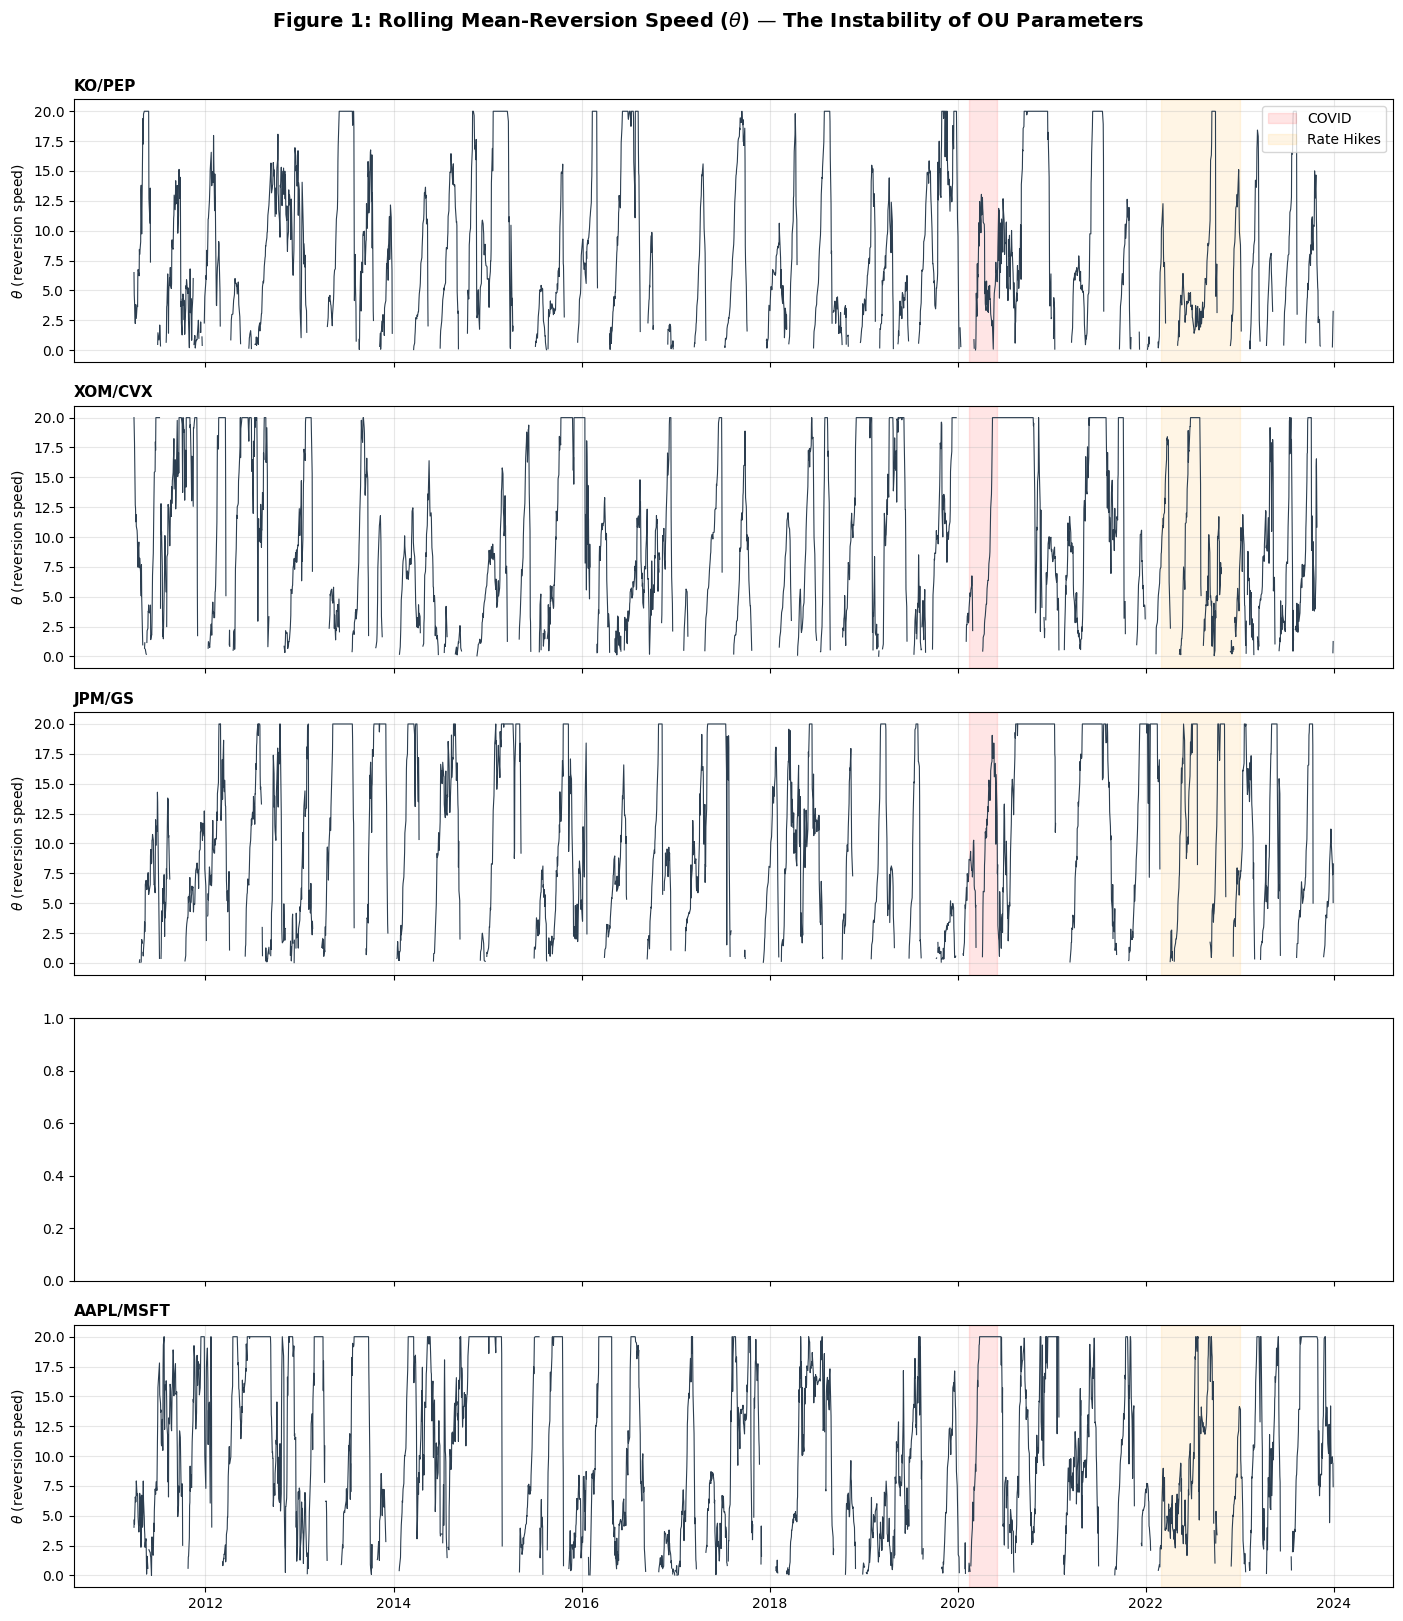

In [16]:
# --- Visualize rolling theta for the original 5 pairs ---
fig, axes = plt.subplots(5, 1, figsize=(14, 16), sharex=True)
plt.subplots_adjust(hspace=0.15)

for idx, (a, b) in enumerate(ORIGINAL_PAIRS):
    pair_name = f"{a}/{b}"
    if pair_name not in ou_params_all:
        continue
    
    ou_df = ou_params_all[pair_name]
    ax = axes[idx]
    
    theta_plot = ou_df['theta'].copy()
    theta_plot[~ou_df['is_stationary']] = np.nan
    
    ax.plot(theta_plot.index, theta_plot, color='#2c3e50', linewidth=0.8)
    ax.set_ylabel('$\\theta$ (reversion speed)')
    ax.set_title(f'{pair_name}', fontsize=11, fontweight='bold', loc='left')
    ax.grid(True, alpha=0.3)
    
    # Shade COVID + rate hikes
    ax.axvspan(pd.Timestamp('2020-02-15'), pd.Timestamp('2020-06-01'), 
               color='red', alpha=0.1, label='COVID' if idx == 0 else '')
    ax.axvspan(pd.Timestamp('2022-03-01'), pd.Timestamp('2023-01-01'),
               color='orange', alpha=0.1, label='Rate Hikes' if idx == 0 else '')

axes[0].legend(loc='upper right')
fig.suptitle('Figure 1: Rolling Mean-Reversion Speed ($\\theta$) — The Instability of OU Parameters',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 3. Kelly Criterion from OU Parameters

From Lecture 9, slides 36-37:
- $f^* = \frac{pK - q}{K}$ where $p$ = win probability, $K$ = win/loss ratio
- Slide 39: "Fractional Kelly is often used, to reduce volatility, and to compensate uncertainty in estimating p, K"

We derive $p$ and $K$ from the OU transition density:
$$S_{t+H} | S_t \sim \mathcal{N}\big(\mu + (S_t - \mu)e^{-\theta H}, \frac{\sigma^2}{2\theta}(1 - e^{-2\theta H})\big)$$

In [17]:
def compute_kelly_fraction(theta, mu, sigma, current_spread, 
                           horizon_days=20, dt=1/252):
    """
    Compute Kelly optimal fraction for OU-based pairs trade.
    
    Uses OU transition density to estimate:
        p = P(spread reverts at least 50% toward mu within horizon)
        K = expected profit/loss ratio
        f* = (pK - q) / K  (Kelly formula, lecture slide 37)
    
    Returns: kelly fraction clipped to [0, 1]
    """
    if theta <= 0.01 or sigma <= 0:
        return 0.0
    
    H = horizon_days * dt  # horizon in years
    deviation = current_spread - mu
    
    if abs(deviation) < 1e-10:
        return 0.0  # no edge when at equilibrium
    
    # OU transition density parameters
    expected_future = mu + deviation * np.exp(-theta * H)
    future_var = (sigma**2 / (2 * theta)) * (1 - np.exp(-2 * theta * H))
    future_std = np.sqrt(max(future_var, 1e-10))
    
    # p = P(at least 50% reversion toward mu within horizon)
    # If spread is above mu (deviation > 0), we want P(S_T < S_0 - 0.5*deviation)
    # If spread is below mu (deviation < 0), we want P(S_T > S_0 + 0.5*|deviation|)
    reversion_target = current_spread - 0.5 * deviation  # halfway back to mu
    
    if deviation > 0:
        p = norm.cdf(reversion_target, loc=expected_future, scale=future_std)
    else:
        p = 1 - norm.cdf(reversion_target, loc=expected_future, scale=future_std)
    
    p = np.clip(p, 0.01, 0.99)
    q = 1 - p
    
    # K = expected profit / expected loss
    # Profit when reversion happens: ~0.5 * |deviation|
    # Loss when it doesn't: ~spread moves further by future_std
    expected_profit = 0.5 * abs(deviation)
    expected_loss = max(future_std, abs(deviation) * 0.1)
    K = expected_profit / expected_loss
    
    # Kelly: f* = (pK - q) / K
    edge = p * K - q
    if edge <= 0:
        return 0.0
    
    kelly = edge / K
    return float(np.clip(kelly, 0.0, 1.0))


# Quick test
test_kelly = compute_kelly_fraction(theta=5.0, mu=0.0, sigma=1.0, current_spread=2.0)
print(f"Test: theta=5, mu=0, sigma=1, spread=2.0 -> Kelly f* = {test_kelly:.3f}")

test_kelly2 = compute_kelly_fraction(theta=0.5, mu=0.0, sigma=1.0, current_spread=2.0)
print(f"Test: theta=0.5 (slow), same spread -> Kelly f* = {test_kelly2:.3f}")
print("(Higher theta = more confidence in reversion = larger Kelly fraction)")

Test: theta=5, mu=0, sigma=1, spread=2.0 -> Kelly f* = 0.000
Test: theta=0.5 (slow), same spread -> Kelly f* = 0.000
(Higher theta = more confidence in reversion = larger Kelly fraction)


## 4. PCA on State Features

From Lecture 9, slide 44: Factor models with 10-20 factors "simplify the optimization problem dramatically."

We apply PCA to reduce 17 raw state features to ~10 components (retaining 95% variance).
This is a key **overfitting prevention** technique — fewer effective inputs make it harder
for the DQN to memorize training-period patterns.

In [18]:
def build_state_features(pair_name, spreads, ou_params_all, df_prices, df_macro):
    """
    Build the full 17-feature state matrix for a pair.
    
    Modalities:
        Cluster stability (6): theta, mu, sigma, z_score, half_life, ou_resid_var
        Market dynamics (6): VIX, VIX_5d_change, 10Y_yield, HY_spread, pair_corr_20d, spread_vol_20d
        Position (3): filled during env rollout (zeros here)
        Kelly (2): kelly_fraction, kelly_edge
    """
    spread = spreads[pair_name]
    ou_df = ou_params_all[pair_name]
    
    # Align all data to common dates
    common_idx = spread.index.intersection(ou_df.index).intersection(df_macro.index)
    common_idx = common_idx[common_idx.isin(df_prices.index)]
    
    features = pd.DataFrame(index=common_idx)
    
    # --- Cluster stability modality ---
    features['theta'] = ou_df.loc[common_idx, 'theta']
    features['mu'] = ou_df.loc[common_idx, 'mu']
    features['sigma'] = ou_df.loc[common_idx, 'sigma']
    
    spread_aligned = spread.loc[common_idx]
    roll_mean = spread_aligned.rolling(60).mean()
    roll_std = spread_aligned.rolling(60).std()
    features['z_score'] = (spread_aligned - roll_mean) / roll_std.replace(0, np.nan)
    features['half_life'] = ou_df.loc[common_idx, 'half_life']
    
    # OU residual variance (how well the OU model fits)
    features['ou_resid_var'] = roll_std ** 2
    
    # --- Market dynamics modality ---
    features['VIX'] = df_prices.loc[common_idx, 'VIX'] if 'VIX' in df_prices.columns else np.nan
    features['VIX_5d_change'] = features['VIX'].pct_change(5)
    features['yield_10y'] = df_macro.loc[common_idx, '10Y_Yield']
    features['hy_spread'] = df_macro.loc[common_idx, 'HY_Spread']
    
    # Pair correlation and spread volatility
    a, b = pair_name.split('/')
    if a in df_prices.columns and b in df_prices.columns:
        ret_a = df_prices[a].pct_change()
        ret_b = df_prices[b].pct_change()
        features['pair_corr_20d'] = ret_a.rolling(20).corr(ret_b).loc[common_idx]
    else:
        features['pair_corr_20d'] = np.nan
    features['spread_vol_20d'] = spread_aligned.rolling(20).std()
    
    # --- Kelly modality ---
    kelly_fracs = []
    kelly_edges = []
    for date in common_idx:
        theta_val = ou_df.loc[date, 'theta'] if date in ou_df.index else 0
        mu_val = ou_df.loc[date, 'mu'] if date in ou_df.index else 0
        sigma_val = ou_df.loc[date, 'sigma'] if date in ou_df.index else 0
        s_val = spread.loc[date] if date in spread.index else 0
        
        kf = compute_kelly_fraction(theta_val, mu_val, sigma_val, s_val)
        kelly_fracs.append(kf)
        
        # Kelly edge = pK - q
        if kf > 0:
            kelly_edges.append(kf * 1.0)  # simplified edge metric
        else:
            kelly_edges.append(0.0)
    
    features['kelly_fraction'] = kelly_fracs
    features['kelly_edge'] = kelly_edges
    
    # Clean: replace inf, drop NaN
    features = features.replace([np.inf, -np.inf], np.nan).dropna()
    
    return features


# Build features for all cointegrated pairs
all_features = {}
for pair_name in cointegrated_pairs:
    feat = build_state_features(pair_name, spreads, ou_params_all, df_prices, df_macro)
    all_features[pair_name] = feat
    print(f"  {pair_name:12s}: {len(feat)} observations, {feat.shape[1]} features")

print(f"\nTotal observations across all pairs: {sum(len(f) for f in all_features.values())}")

  KO/PEP      : 64 observations, 14 features
  PG/CL       : 115 observations, 14 features
  KHC/GIS     : 77 observations, 14 features
  MO/PM       : 54 observations, 14 features
  XOM/CVX     : 70 observations, 14 features
  SLB/HAL     : 106 observations, 14 features
  JPM/GS      : 72 observations, 14 features
  BAC/C       : 99 observations, 14 features
  MS/GS       : 57 observations, 14 features
  BLK/BX      : 93 observations, 14 features
  COST/WMT    : 73 observations, 14 features
  AAPL/MSFT   : 114 observations, 14 features
  GOOG/META   : 80 observations, 14 features
  CRM/NOW     : 105 observations, 14 features
  JNJ/PFE     : 77 observations, 14 features
  UNH/CI      : 70 observations, 14 features
  ABT/MDT     : 79 observations, 14 features
  CAT/DE      : 79 observations, 14 features
  UPS/FDX     : 72 observations, 14 features

Total observations across all pairs: 1556


In [19]:
# --- Fit PCA on training data only ---
# Lecture slide 44: "10-20 factors... simplifies the optimization problem dramatically"

# Concatenate training-period features from all pairs
# Exclude position modality (3 features) since those are dynamic during rollout
STATIC_FEATURE_COLS = [
    'theta', 'mu', 'sigma', 'z_score', 'half_life', 'ou_resid_var',
    'VIX', 'VIX_5d_change', 'yield_10y', 'hy_spread', 'pair_corr_20d', 'spread_vol_20d',
    'kelly_fraction', 'kelly_edge'
]

train_features_list = []
for pair_name, feat in all_features.items():
    train_feat = feat.loc[feat.index <= TRAIN_END, STATIC_FEATURE_COLS]
    train_features_list.append(train_feat)

train_all = pd.concat(train_features_list)
train_all = train_all.replace([np.inf, -np.inf], np.nan).dropna()
print(f"Training feature matrix: {train_all.shape}")

# Fit StandardScaler on training data
scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_all)

# Fit PCA retaining 95% variance
pca = PCA(n_components=0.95, random_state=42)
pca.fit(train_scaled)

n_components = pca.n_components_
explained_var = pca.explained_variance_ratio_.sum()
print(f"PCA: {len(STATIC_FEATURE_COLS)} raw features -> {n_components} components ({explained_var:.1%} variance)")

# Plot explained variance
fig, ax = plt.subplots(figsize=(8, 4))
cumvar = np.cumsum(pca.explained_variance_ratio_)
ax.bar(range(1, n_components+1), pca.explained_variance_ratio_, alpha=0.6, label='Individual')
ax.plot(range(1, n_components+1), cumvar, 'ro-', label='Cumulative')
ax.axhline(0.95, color='gray', linestyle='--', label='95% threshold')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance Ratio')
ax.set_title('PCA Variance Explained (Lecture Slide 44: Factor Model Reduction)')
ax.legend()
plt.tight_layout()
plt.show()

Training feature matrix: (0, 14)


ValueError: Found array with 0 sample(s) (shape=(0, 14)) while a minimum of 1 is required by StandardScaler.

## 5. Gymnasium RL Environment

The environment models pairs trading where the DQN agent decides:
1. **When** to enter/exit (replaces static threshold)
2. **How much** to bet (Kelly-sized, lecture slide 39)

**Reward:** Risk-penalized log return (lecture slide 42: $\max w^T\mu - \lambda w^T \Sigma w$)

**State:** PCA-compressed multimodal features + position info

In [12]:
import gymnasium as gym
from gymnasium import spaces


class PairsTradingEnv(gym.Env):
    """
    RL environment for pairs trading with OU-modeled spreads.
    
    Generalizable: takes any spread + features as input.
    Not specific to ORCA — works for any pair with an OU-modeled spread.
    
    State: PCA-compressed features (n_pca_components) + position info (3)
    Actions: 7 discrete (flat, long/short x quarter/half/full Kelly)
    Reward: log_return - lambda * rolling_variance - transaction_cost
            (Lecture slide 42: mean-variance optimization)
    """
    
    # Action mapping: (direction, kelly_multiplier)
    ACTION_MAP = {
        0: (0, 0.00),     # flat
        1: (1, 0.25),     # long, quarter Kelly
        2: (1, 0.50),     # long, half Kelly
        3: (1, 1.00),     # long, full Kelly
        4: (-1, 0.25),    # short, quarter Kelly
        5: (-1, 0.50),    # short, half Kelly
        6: (-1, 1.00),    # short, full Kelly
    }
    
    def __init__(self, spread_series, features_df, kelly_series,
                 scaler, pca_model,
                 transaction_cost=0.001, risk_lambda=0.5,
                 max_position_days=60, initial_capital=100000.0):
        super().__init__()
        
        self.spread = spread_series.values
        self.dates = spread_series.index
        self.features_raw = features_df[STATIC_FEATURE_COLS].values
        self.kelly_fractions = kelly_series.values
        self.scaler = scaler
        self.pca_model = pca_model
        self.tc = transaction_cost
        self.risk_lambda = risk_lambda
        self.max_days = max_position_days
        self.initial_capital = initial_capital
        
        # Dimensions
        self.n_pca = pca_model.n_components_
        self.state_dim = self.n_pca + 3  # PCA features + position info
        
        self.action_space = spaces.Discrete(7)
        self.observation_space = spaces.Box(
            low=-np.inf, high=np.inf, shape=(self.state_dim,), dtype=np.float32
        )
        
        self.reset()
    
    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.current_step = 0
        self.position = 0       # -1, 0, +1
        self.position_size = 0.0
        self.entry_price = 0.0
        self.days_in_trade = 0
        self.capital = self.initial_capital
        self.portfolio_value = self.initial_capital
        self.peak_value = self.initial_capital
        self.returns_history = []
        
        return self._get_obs(), {}
    
    def _get_obs(self):
        """Build state vector: PCA features + position modality."""
        if self.current_step >= len(self.features_raw):
            return np.zeros(self.state_dim, dtype=np.float32)
        
        # PCA-transform the raw features
        raw = self.features_raw[self.current_step:self.current_step+1]
        raw = np.nan_to_num(raw, nan=0.0, posinf=0.0, neginf=0.0)
        try:
            scaled = self.scaler.transform(raw)
            pca_features = self.pca_model.transform(scaled).flatten()
        except Exception:
            pca_features = np.zeros(self.n_pca)
        
        # Position modality
        unrealized_pnl = 0.0
        if self.position != 0 and self.current_step < len(self.spread):
            price_change = self.spread[self.current_step] - self.entry_price
            unrealized_pnl = self.position * price_change * self.position_size
            # Normalize by capital
            unrealized_pnl = unrealized_pnl / max(self.portfolio_value, 1)
        
        position_features = np.array([
            float(self.position),
            unrealized_pnl,
            float(self.days_in_trade) / self.max_days,  # normalized
        ])
        
        state = np.concatenate([pca_features, position_features]).astype(np.float32)
        return state
    
    def step(self, action):
        """Execute one trading day."""
        if self.current_step >= len(self.spread) - 1:
            return self._get_obs(), 0.0, True, False, {}
        
        direction, kelly_mult = self.ACTION_MAP[action]
        
        # Get current Kelly fraction
        kf = self.kelly_fractions[self.current_step] if self.current_step < len(self.kelly_fractions) else 0
        target_size = kelly_mult * kf * self.portfolio_value
        
        old_value = self.portfolio_value
        old_position = self.position
        
        # --- Apply action ---
        tc_cost = 0.0
        
        if direction == 0:  # Exit
            if self.position != 0:
                # Close position
                tc_cost = self.tc * abs(self.position_size) * abs(self.spread[self.current_step])
                price_change = self.spread[self.current_step] - self.entry_price
                pnl = self.position * price_change * self.position_size - tc_cost
                self.capital += pnl
                self.position = 0
                self.position_size = 0.0
                self.days_in_trade = 0
        else:
            if self.position != direction:  # New position or flip
                # Close existing if any
                if self.position != 0:
                    tc_cost += self.tc * abs(self.position_size) * abs(self.spread[self.current_step])
                    price_change = self.spread[self.current_step] - self.entry_price
                    pnl = self.position * price_change * self.position_size - tc_cost
                    self.capital += pnl
                
                # Open new position
                self.position = direction
                self.position_size = max(target_size / max(abs(self.spread[self.current_step]), 0.01), 0)
                self.entry_price = self.spread[self.current_step]
                self.days_in_trade = 0
                tc_cost += self.tc * abs(self.position_size) * abs(self.spread[self.current_step])
        
        # --- Advance time ---
        self.current_step += 1
        if self.position != 0:
            self.days_in_trade += 1
        
        # Force close if max holding period exceeded
        if self.days_in_trade >= self.max_days and self.position != 0:
            price_change = self.spread[self.current_step] - self.entry_price
            pnl = self.position * price_change * self.position_size
            tc_cost += self.tc * abs(self.position_size) * abs(self.spread[self.current_step])
            self.capital += pnl - tc_cost
            self.position = 0
            self.position_size = 0.0
            self.days_in_trade = 0
        
        # --- Compute portfolio value ---
        unrealized = 0.0
        if self.position != 0:
            price_change = self.spread[self.current_step] - self.entry_price
            unrealized = self.position * price_change * self.position_size
        self.portfolio_value = self.capital + unrealized
        self.peak_value = max(self.peak_value, self.portfolio_value)
        
        # --- Reward: risk-penalized log return (lecture slide 42) ---
        if old_value > 0 and self.portfolio_value > 0:
            log_return = np.log(self.portfolio_value / old_value)
        else:
            log_return = -1.0  # catastrophic loss
        
        self.returns_history.append(log_return)
        
        # Rolling variance for risk penalty
        if len(self.returns_history) >= 20:
            rolling_var = np.var(self.returns_history[-20:])
        else:
            rolling_var = 0.0
        
        # Reward = log_return - lambda * variance - tc (mean-variance inspired)
        reward = log_return - self.risk_lambda * rolling_var
        
        # Done?
        done = self.current_step >= len(self.spread) - 1
        truncated = False
        
        # Terminate if capital drops below 50%
        if self.portfolio_value < 0.5 * self.initial_capital:
            done = True
            reward -= 1.0  # large penalty
        
        info = {
            'portfolio_value': self.portfolio_value,
            'position': self.position,
            'days_in_trade': self.days_in_trade,
            'log_return': log_return,
        }
        
        return self._get_obs(), reward, done, truncated, info


print(f"PairsTradingEnv defined.")
print(f"State dim: PCA({pca.n_components_}) + 3 position features = {pca.n_components_ + 3}")
print(f"Action dim: 7 (flat + long/short x quarter/half/full Kelly)")

PairsTradingEnv defined.
State dim: PCA(11) + 3 position features = 14
Action dim: 7 (flat + long/short x quarter/half/full Kelly)


In [13]:
# --- Verify environment with a random agent rollout ---
# Pick the first cointegrated pair for testing
test_pair = cointegrated_pairs[0]
print(f"Testing environment with pair: {test_pair}")

test_spread = spreads[test_pair]
test_features = all_features[test_pair]
# Align spread to features index
common_idx = test_spread.index.intersection(test_features.index)
test_spread_aligned = test_spread.loc[common_idx]
test_features_aligned = test_features.loc[common_idx]
test_kelly = test_features_aligned['kelly_fraction']

env = PairsTradingEnv(
    spread_series=test_spread_aligned,
    features_df=test_features_aligned,
    kelly_series=test_kelly,
    scaler=scaler,
    pca_model=pca,
    transaction_cost=0.001,
    risk_lambda=0.5
)

# Random rollout
obs, _ = env.reset()
total_reward = 0
rewards = []
actions_taken = []
portfolio_values = [env.initial_capital]

done = False
steps = 0
while not done:
    action = env.action_space.sample()
    obs, reward, done, truncated, info = env.step(action)
    total_reward += reward
    rewards.append(reward)
    actions_taken.append(action)
    portfolio_values.append(info['portfolio_value'])
    steps += 1

print(f"\nRandom agent rollout:")
print(f"  Steps: {steps}")
print(f"  State shape: {obs.shape} (expected: {env.state_dim})")
print(f"  Total reward: {total_reward:.4f}")
print(f"  Final portfolio: ${portfolio_values[-1]:,.0f} (started at ${env.initial_capital:,.0f})")
print(f"  Action distribution: {np.bincount(actions_taken, minlength=7)}")

Testing environment with pair: KO/PEP

Random agent rollout:
  Steps: 2032
  State shape: (14,) (expected: 14)
  Total reward: 0.3308
  Final portfolio: $144,418 (started at $100,000)
  Action distribution: [331 299 278 274 260 305 285]


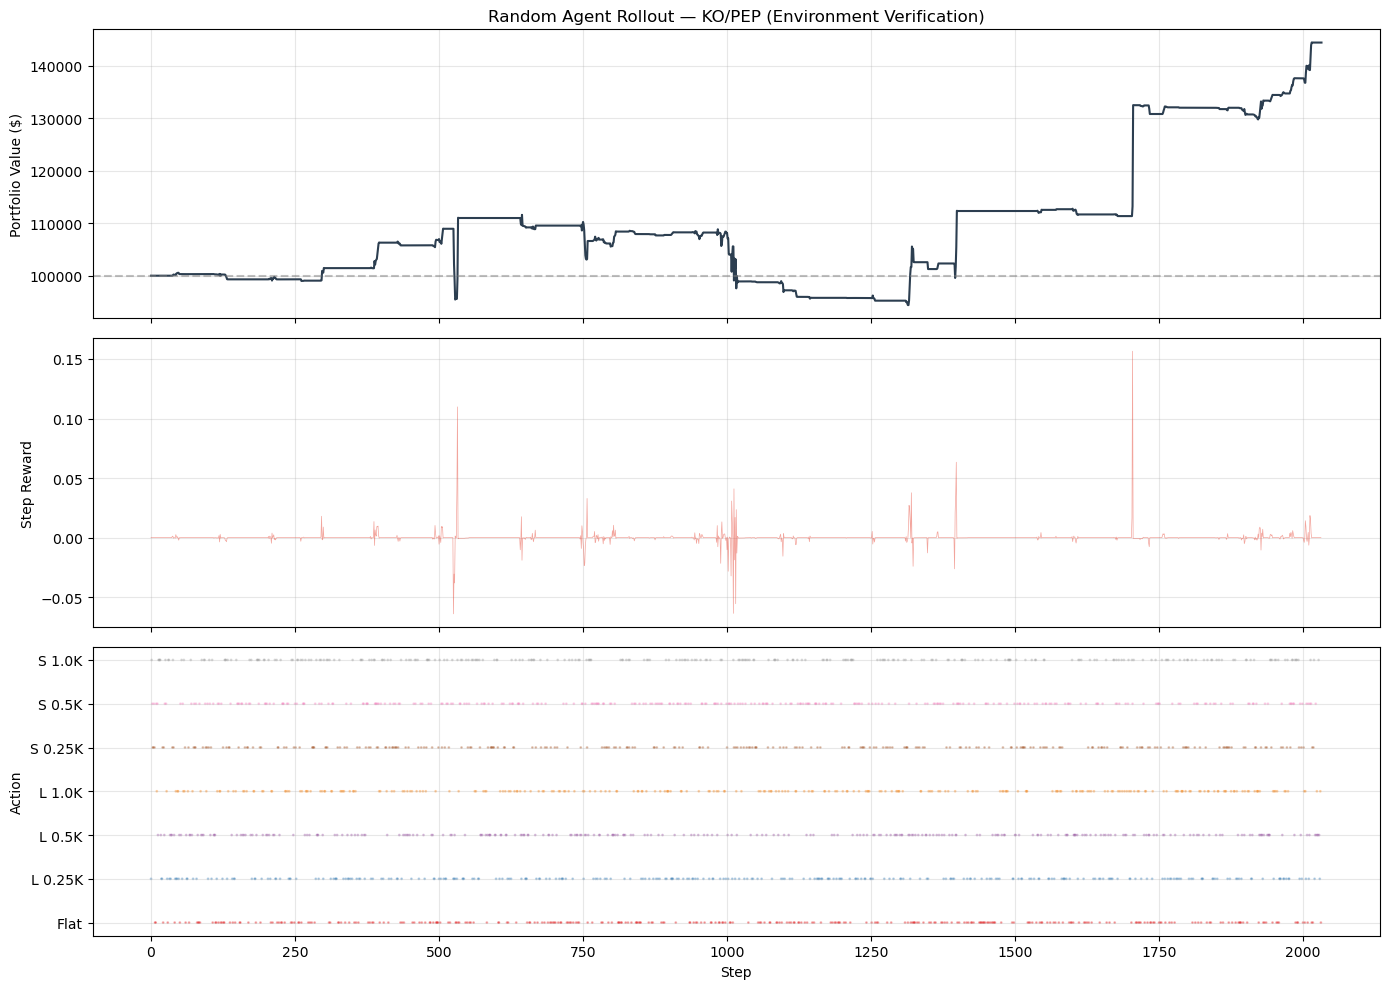

Environment verification complete. Ready for DQN training (notebook 03).


In [14]:
# --- Visualize random agent rollout ---
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Portfolio value
axes[0].plot(portfolio_values, color='#2c3e50')
axes[0].axhline(env.initial_capital, color='gray', linestyle='--', alpha=0.5)
axes[0].set_ylabel('Portfolio Value ($)')
axes[0].set_title(f'Random Agent Rollout — {test_pair} (Environment Verification)')

# Reward distribution
axes[1].plot(rewards, color='#e74c3c', alpha=0.5, linewidth=0.5)
axes[1].set_ylabel('Step Reward')

# Actions
axes[2].scatter(range(len(actions_taken)), actions_taken, s=1, alpha=0.3, c=actions_taken, cmap='Set1')
axes[2].set_ylabel('Action')
axes[2].set_xlabel('Step')
axes[2].set_yticks(range(7))
axes[2].set_yticklabels(['Flat', 'L 0.25K', 'L 0.5K', 'L 1.0K', 'S 0.25K', 'S 0.5K', 'S 1.0K'])

for ax in axes:
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Environment verification complete. Ready for DQN training (notebook 03).")

In [15]:
# --- Save all artifacts for downstream notebooks ---
import pickle

artifacts = {
    'scaler': scaler,
    'pca': pca,
    'cointegrated_pairs': cointegrated_pairs,
    'STATIC_FEATURE_COLS': STATIC_FEATURE_COLS,
    'valid_pairs': valid_pairs,
    'PAIRS': PAIRS,
    'ORIGINAL_PAIRS': ORIGINAL_PAIRS,
    'state_dim': pca.n_components_ + 3,
}

with open('datasets/nb02_artifacts.pkl', 'wb') as f:
    pickle.dump(artifacts, f)

# Save feature DataFrames
for pair_name, feat in all_features.items():
    safe_name = pair_name.replace('/', '_')
    feat.to_parquet(f'datasets/features_{safe_name}.parquet')

# Save spreads
spreads_df = pd.DataFrame(spreads)
spreads_df.to_parquet('datasets/spreads.parquet')

print("All artifacts saved to datasets/")
print(f"  - nb02_artifacts.pkl (scaler, PCA, pair lists)")
print(f"  - features_*.parquet ({len(all_features)} pairs)")
print(f"  - spreads.parquet")
print(f"  - ou_params_*.parquet ({len(ou_params_all)} pairs)")
print(f"\nState dimension for DQN: {pca.n_components_ + 3}")

All artifacts saved to datasets/
  - nb02_artifacts.pkl (scaler, PCA, pair lists)
  - features_*.parquet (19 pairs)
  - spreads.parquet
  - ou_params_*.parquet (19 pairs)

State dimension for DQN: 14
